# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
from sklearn import linear_model
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

### 1,2) Creating the dataframe

In [2]:
df = pd.read_csv("../data/checker_submits.csv", parse_dates=["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.day_of_week
df.drop("timestamp", axis=1, inplace=True)

In [3]:
display(df)

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


### 3) OneHotEncoder

Теперь переведем колонки _uid_ and _labname_ в цифровой вид:

"One Hot Encoding is a method for converting categorical variables into a binary format. It creates new columns for each category where 1 means the category is present and 0 means it is not. The primary purpose of One Hot Encoding is to ensure that categorical data can be effectively used in machine learning models
For example, many categorical variables have no inherent order (e.g., “Male” and “Female”). If we were to assign numerical values (e.g., Male = 0, Female = 1) the model might mistakenly interpret this as a ranking and lead to biased predictions. One Hot Encoding eliminates this risk by treating each category independently."

Articles: [One Hot Encoding in Machine Learning by Geeksforgeeks](https://www.geeksforgeeks.org/ml-one-hot-encoding/), [Отличия LabelEncoder и OneHotEncoder в SciKit Learn](https://habr.com/ru/articles/456294/)

In [4]:
cols = ["uid", "labname"]
categorical_columns = df[cols] # объявляем какие колонки нужно закодировать
encoder = OneHotEncoder(sparse_output=False) # не возвращать разряженную матрицу
encoded_columns = encoder.fit_transform(categorical_columns)

one_hot_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(cols)) # создаем из полученных значений таблицу 
                                                                                        # с колонками под названиями columns
df_encoded = pd.concat([df, one_hot_df], axis=1)
df_encoded.drop(columns=cols, inplace=True)
display(df_encoded)

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,9,20,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,6,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,7,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,8,20,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 4) StandartScaler

_StandardScaler_ standardizes features by removing the mean and scaling to unit variance. It transforms the data to have a mean of 0 and a standard deviation of 1. This process is also known as z-score normalization

_When to Use StandardScaler?_

Normally Distributed Data: Best suited for data that follows a Gaussian (normal) distribution.
Algorithms Sensitive to Feature Scales: Useful for algorithms like Support Vector Machines (SVM), k-Nearest Neighbors (k-NN), and logistic regression that are sensitive to the scale of the data.

Article: [Difference Between StandardScaler and Normalizer in sklearn.preprocessing](https://www.geeksforgeeks.org/difference-between-standardscaler-and-normalizer-in-sklearn-preprocessing/)

Колонки numTrials и hour можно рассматривать как непрерывные величины, нормализуем их:

In [5]:
scaler = StandardScaler()
df_encoded[['numTrials', 'hour']] = scaler.fit_transform(df_encoded[['numTrials', 'hour']])

In [6]:
display(df_encoded)

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 5) Saving to the file

In [7]:
df_encoded.to_csv("dayofweek.csv", index=False)

### 6) Naive algorithm

Пусть результат - самый популярный день недели

In [8]:
res = df_encoded['dayofweek'].mode()[0]

Полагая, что наимвный алгоритм предсказывает день недели как просто самый популярный день, посчитаем сколько совпало:

In [9]:
length = len(df_encoded)
accuracy = 0
for index, row in df_encoded.iterrows():
    if row["dayofweek"] == res:
        accuracy += 1

print(accuracy / length)


0.23487544483985764


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

#### 1, 2) LogReg and Accuracy

In [10]:
reg = linear_model.LogisticRegression(random_state=21, fit_intercept=False)
X = df_encoded.drop(["dayofweek"], axis=1)
Y = df_encoded["dayofweek"]
reg.fit(X, Y)
accuracy_score(df_encoded["dayofweek"], reg.predict(X))


0.6405693950177936

#### 3) The plot

Функция определяет самые существенные признаки по их весам Wi в coef:

In [11]:
def barh(coef: list, features, top: int):
    """Принимает coef как одномерный масив
    features - dataframe
    """

    sorted_indexes = coef.argsort()[::-1][:top]
    
    fig, ax = plt.subplots(figsize=(15, 8))
    plt.barh(features[sorted_indexes], coef[sorted_indexes], color="maroon")
    plt.title("The most important features")
    ax.invert_yaxis()
    plt.show()
    

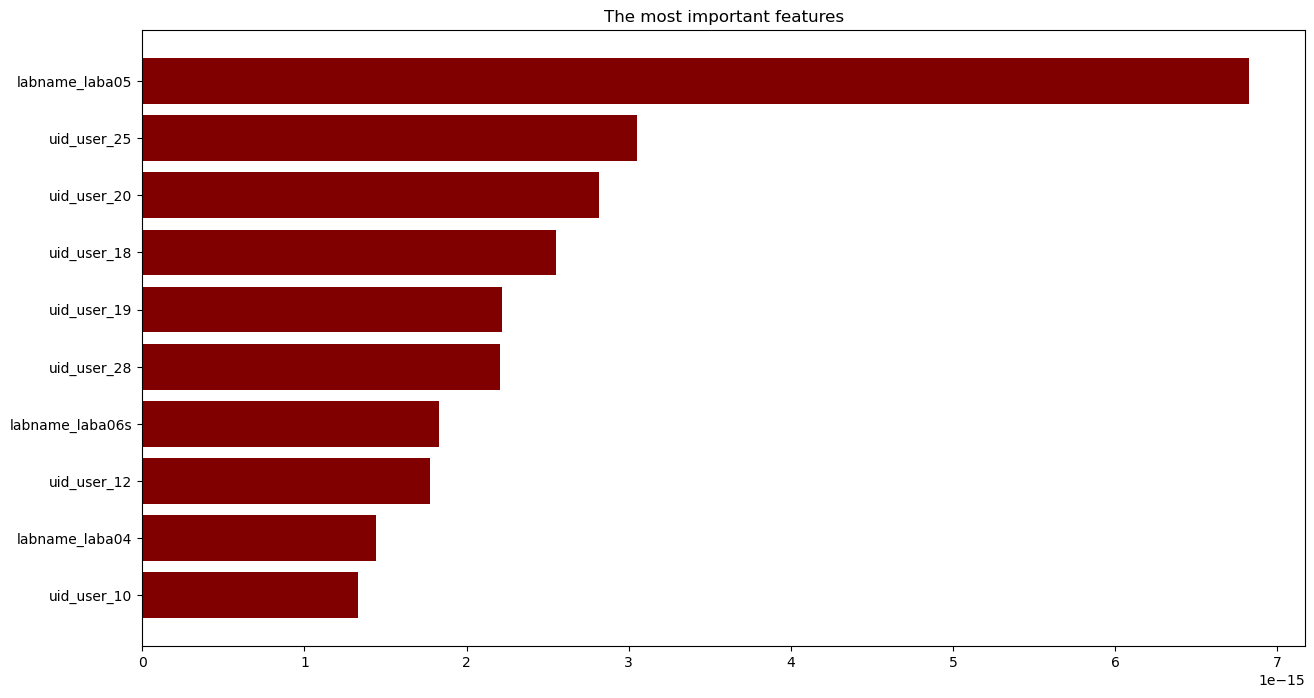

In [12]:
barh(coef=reg.coef_.sum(axis=0), features=df_encoded.drop(["dayofweek"], axis=1).columns, top=10)    # возьмем средние коэффициенты по строкам

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

#### 1,2) Попробуем разные ядра:

In [13]:
kernels = ["linear", "poly", "rbf", "sigmoid"]

In [14]:
for k in kernels:
    svc = SVC(kernel=k, probability=True, random_state=21)
    svc.fit(X, Y)
    print(f"{k} kernel: {accuracy_score(df_encoded["dayofweek"], svc.predict(X))} accuracy")

linear kernel: 0.702846975088968 accuracy
poly kernel: 0.8594306049822064 accuracy
rbf kernel: 0.8558718861209964 accuracy
sigmoid kernel: 0.3997627520759193 accuracy


Таким образом, полиномиальное ядро оказалась лучшим для задачи

#### 3) Plotting barh

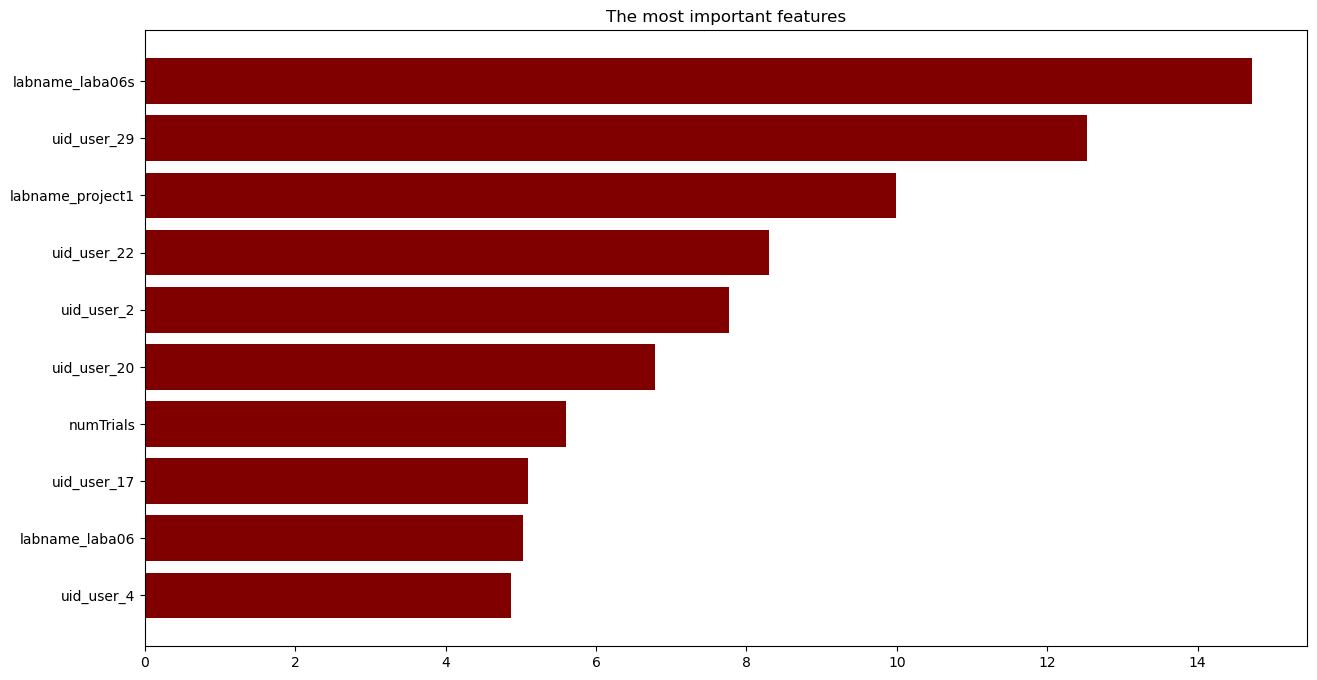

In [15]:
svc = SVC(kernel="linear", probability=True, random_state=21)
svc.fit(X, Y)

barh(coef=svc.coef_.sum(axis=0), features=df_encoded.drop(["dayofweek"], axis=1).columns, top=10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

#### 2) Trying different accuracies

In [16]:
for d in range(1, 30):
    clf = DecisionTreeClassifier(max_depth=d, random_state=21)
    clf.fit(X, Y)
    acc = accuracy_score(df_encoded["dayofweek"], clf.predict(X))
    print(f"depth = {d}     accuracy = {acc}")
    if acc >= 1:
        break


depth = 1     accuracy = 0.35765124555160144
depth = 2     accuracy = 0.4389086595492289
depth = 3     accuracy = 0.48991696322657174
depth = 4     accuracy = 0.5516014234875445
depth = 5     accuracy = 0.6109134045077106
depth = 6     accuracy = 0.6637010676156584
depth = 7     accuracy = 0.7064056939501779
depth = 8     accuracy = 0.7502965599051008
depth = 9     accuracy = 0.7846975088967971
depth = 10     accuracy = 0.8196915776986952
depth = 11     accuracy = 0.8499406880189798
depth = 12     accuracy = 0.8831553973902728
depth = 13     accuracy = 0.9104389086595492
depth = 14     accuracy = 0.9317912218268091
depth = 15     accuracy = 0.9460260972716489
depth = 16     accuracy = 0.9608540925266904
depth = 17     accuracy = 0.9709371293001187
depth = 18     accuracy = 0.9798339264531435
depth = 19     accuracy = 0.9839857651245552
depth = 20     accuracy = 0.9869513641755635
depth = 21     accuracy = 0.9905100830367735
depth = 22     accuracy = 0.9922894424673784
depth = 23     ac

#### 1,3) Plotting the barh

Коэффициенты дерева решений:

In [17]:
clf.feature_importances_

array([0.36514456, 0.09804026, 0.        , 0.00704226, 0.0153667 ,
       0.00388943, 0.02705129, 0.02196882, 0.02504196, 0.00343675,
       0.00730214, 0.01205799, 0.00604265, 0.01090594, 0.02767534,
       0.01516113, 0.01421868, 0.004294  , 0.00382282, 0.01265378,
       0.01428106, 0.02181804, 0.00726097, 0.01827014, 0.0246552 ,
       0.02687622, 0.00728539, 0.01417791, 0.02232321, 0.0012573 ,
       0.        , 0.00578597, 0.00505058, 0.00243772, 0.        ,
       0.        , 0.00095294, 0.01506702, 0.00599161, 0.02377655,
       0.01063544, 0.01548076, 0.07549943])

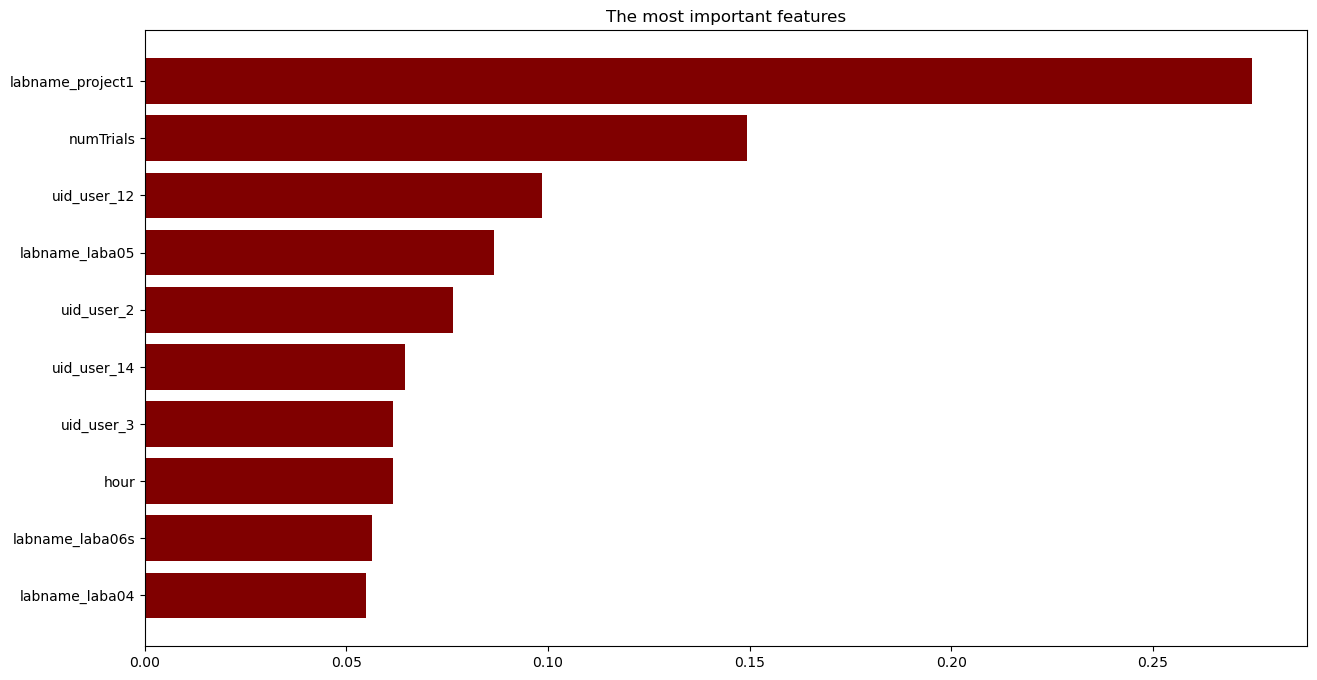

In [18]:
clf = DecisionTreeClassifier(max_depth=4, random_state=21)
clf.fit(X, Y)
barh(coef=clf.feature_importances_, features=df_encoded.drop(["dayofweek"], axis=1).columns, top=10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

Random Forest is a method that combines the predictions of multiple decision trees to produce a more accurate and stable result. It can be used for both classification and regression tasks.

In classification tasks, Random Forest Classification predicts categorical outcomes based on the input data. It uses multiple decision trees and outputs the label that has the maximum votes among all the individual tree predictions

* _n_estimators_: Number of trees in the forest
* _max_depth_: Maximum depth of each tree

[Random Forest Classifier using Scikit-learn](https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/)

#### 1) Creating the classifier

In [19]:
classifier = RandomForestClassifier(n_estimators=100, random_state=21, max_depth=25)
classifier.fit(X, Y)
y_pred = classifier.predict(X)

#### 2) Testing parameters

depth: 10  n_estimators: 50     accuracy: 0.8701067615658363
depth: 10  n_estimators: 60     accuracy: 0.8766310794780545
depth: 10  n_estimators: 70     accuracy: 0.8766310794780545
depth: 10  n_estimators: 80     accuracy: 0.8778173190984578
depth: 10  n_estimators: 90     accuracy: 0.8795966785290629
depth: 10  n_estimators: 100     accuracy: 0.8855278766310795
depth: 15  n_estimators: 50     accuracy: 0.9786476868327402
depth: 15  n_estimators: 60     accuracy: 0.9792408066429419
depth: 15  n_estimators: 70     accuracy: 0.9786476868327402
depth: 15  n_estimators: 80     accuracy: 0.9792408066429419
depth: 15  n_estimators: 90     accuracy: 0.9798339264531435
depth: 15  n_estimators: 100     accuracy: 0.9780545670225386
depth: 20  n_estimators: 50     accuracy: 0.9970344009489917
depth: 20  n_estimators: 60     accuracy: 0.9952550415183867
depth: 20  n_estimators: 70     accuracy: 0.9958481613285883
depth: 20  n_estimators: 80     accuracy: 0.9958481613285883
depth: 20  n_estimator

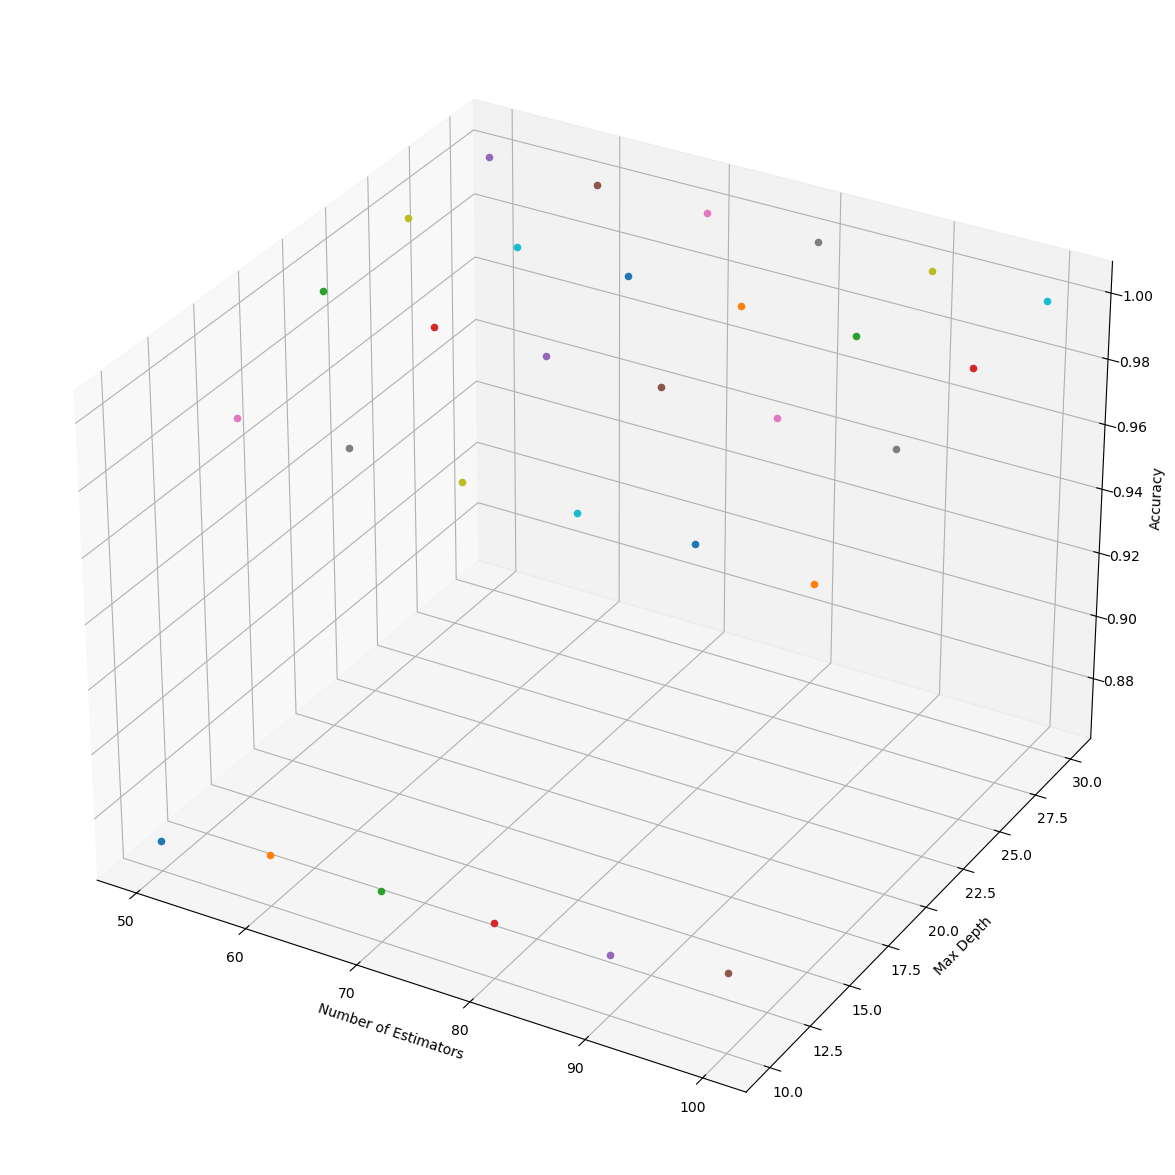

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

for d in range(10, 31, 5):
    for est in range(50, 101, 10):
        forest = RandomForestClassifier(n_estimators=est, random_state=21, max_depth=d)
        forest.fit(X, Y)
        acc = accuracy_score(df_encoded["dayofweek"], forest.predict(X))
        print(f"depth: {d}  n_estimators: {est}     accuracy: {acc}")
        ax.scatter(est, d, acc, marker="o")

ax.set_xlabel('Number of Estimators')
ax.set_ylabel('Max Depth')
ax.set_zlabel('Accuracy')
plt.show()

Из графика и вывода видно, что параметр глубины деревьев влияет на точность предсказаний леса деревьев решений гораздо радикальнее, чем параметр количества деревьев

#### 3) Plotting the barh

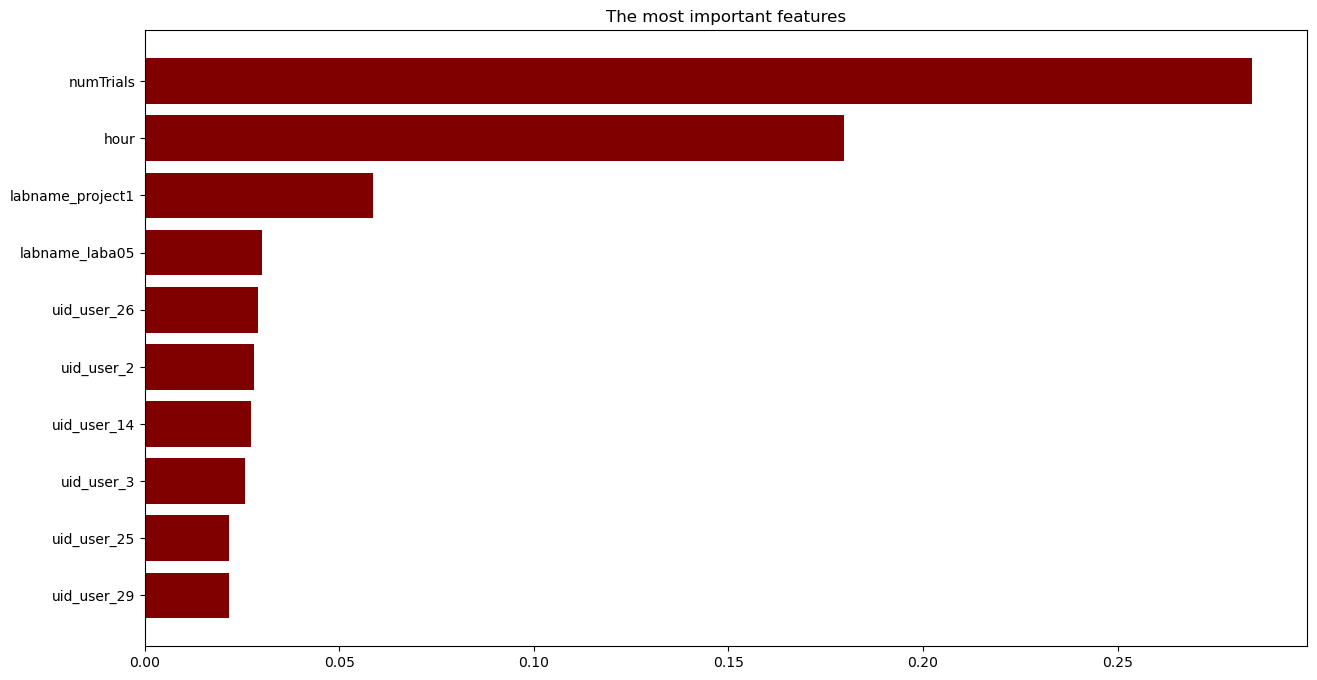

In [21]:
barh(coef=classifier.feature_importances_, features=df_encoded.drop(["dayofweek"], axis=1).columns, top=10)